# Научно-исследовательская работа
## Прогнозирование качества вина на основе химических характеристик

**Студент:** Прокофьев Илья Викторович

**Группа:** РТ5-61Б

**Дата:** 30.04.2026

## 1. Постановка задачи

**Цель:** Построение моделей машинного обучения для прогнозирования качества вина на основе его химических характеристик.

**Тип задачи:** Классификация (качество вина оценивается по шкале от 3 до 9 баллов). Сведена к бинарной классификации (>=6 - хорошее качество)

**Источник данных:** UCI Machine Learning Repository - Wine Quality Dataset

## 2. Импорт необходимых библиотек

Импортируются все необходимые модули: библиотеки для работы с данными (numpy, pandas), 
визуализации (matplotlib, seaborn) и машинного обучения (sklearn). 
Также задаётся стиль графиков и отключаются предупреждения для чистоты вывода.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            classification_report, confusion_matrix, roc_auc_score, cohen_kappa_score, make_scorer)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


## 3. Загрузка данных

In [2]:
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()

Размер датасета: (6497, 13)

Первые 5 строк:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 4. Разведочный анализ данных

## Описание набора данных Wine Quality

### Источник
Данные взяты из UCI Machine Learning Repository: [Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). Они содержат химические характеристики португальских вин "Vinho Verde" (красные и белые варианты).

### Общая характеристика
- **Количество образцов**: 6497 (1599 красных, 4898 белых).
- **Количество признаков**: 11 химических показателей + тип вина.
- **Целевая переменная (исходная)**: `quality` — экспертная оценка качества от 3 до 9.
- **Бинарная цель**: создана переменная `quality_binary = (quality >= 6)`, где 1 — "хорошее вино", 0 — "плохое".

### Признаки
| Признак | Описание |
|--------|----------|
| fixed acidity | Фиксированная кислотность (г/дм³) |
| volatile acidity | Летучая кислотность (г/дм³) |
| citric acid | Лимонная кислота (г/дм³) |
| residual sugar | Остаточный сахар (г/дм³) |
| chlorides | Хлориды (г/дм³) |
| free sulfur dioxide | Свободный диоксид серы (мг/дм³) |
| total sulfur dioxide | Общий диоксид серы (мг/дм³) |
| density | Плотность (г/см³) |
| pH | Водородный показатель |
| sulphates | Сульфаты (г/дм³) |
| alcohol | Содержание алкоголя (% об.) |
| wine_type | Тип вина (red/white) |

В ходе инжиниринга были созданы дополнительные признаки: `free_to_total_sulfur_ratio`, `acid_balance`, `sugar_alcohol_ratio`, `ph_category_encoded`.

### Особенности данных
- Пропусков в данных нет.
- Присутствуют выбросы в некоторых признаках (residual sugar, chlorides, free sulfur dioxide), но они были сохранены как потенциально информативные.
- Распределение качества смещено в сторону средних значений (5–6), что делает задачу бинарной классификации более сбалансированной, чем многоклассовую.

Оценим размер таблицы, типы столбцов и основные статистические характеристики 
(средние, минимумы, максимумы) числовых признаков. Это поможет выявить аномалии 
и понять масштаб величин.

In [4]:
print("Информация о датасете:")
print(df.info())
print("\nСтатистические характеристики:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
 13  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage:

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.633061
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.482007
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


Пропуски могут исказить обучение моделей. Выведем абсолютное количество 
и процент пропусков в каждом столбце.

In [5]:
print("Количество пропусков по столбцам:")
print(df.isnull().sum())
print(f"\nПроцент пропусков: {(df.isnull().sum() / len(df) * 100).round(2)}")

Количество пропусков по столбцам:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
quality_binary          0
dtype: int64

Процент пропусков: fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
wine_type               0.0
quality_binary          0.0
dtype: float64


#### Анализ целевой переменной
Изучим баланс классов качества вина. Сильный дисбаланс может потребовать 
специальных методов (взвешивание классов, специальные метрики). 
Также сравним распределение для красного и белого вина.

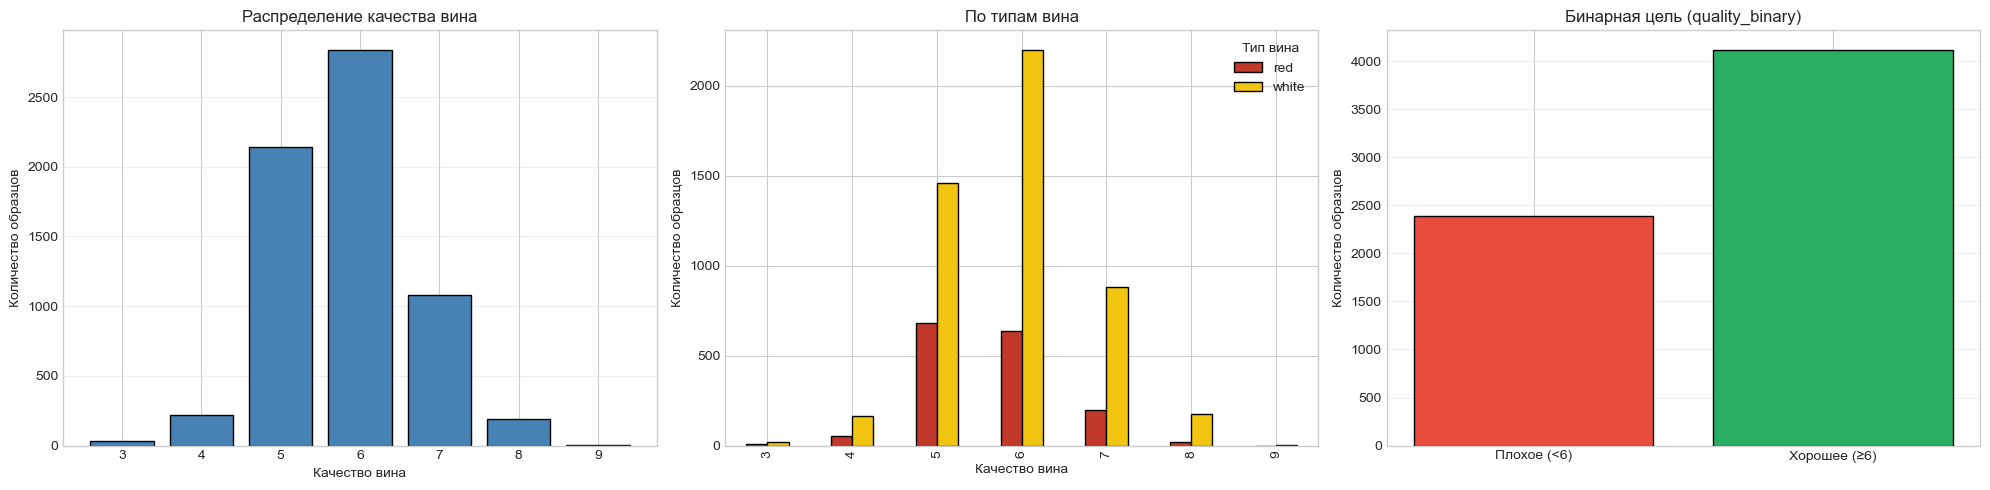

Распределение бинарного качества:
quality_binary
0    2384
1    4113
Name: count, dtype: int64


In [9]:
# Вместо всего вывода quality_counts добавить:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Мультиклассовое распределение (старое)
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Качество вина')
axes[0].set_ylabel('Количество образцов')
axes[0].set_title('Распределение качества вина')
axes[0].grid(axis='y', alpha=0.3)

# 2) Распределение по типам (как раньше)
quality_by_type = df.groupby(['quality', 'wine_type']).size().unstack(fill_value=0)
quality_by_type.plot(kind='bar', ax=axes[1], color=['#c0392b', '#f1c40f'], edgecolor='black')
axes[1].set_xlabel('Качество вина')
axes[1].set_ylabel('Количество образцов')
axes[1].set_title('По типам вина')
axes[1].legend(title='Тип вина')

# 3) Бинарная цель
binary_counts = df['quality_binary'].value_counts().sort_index()
axes[2].bar(binary_counts.index, binary_counts.values, color=['#e74c3c', '#27ae60'], edgecolor='black')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Плохое (<6)', 'Хорошее (≥6)'])
axes[2].set_ylabel('Количество образцов')
axes[2].set_title('Бинарная цель (quality_binary)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Распределение бинарного качества:")
print(df['quality_binary'].value_counts().sort_index())

Задачу многоклассовой классификации при таком маленьком количестве данных и большом дисбалансе решить сложно, поэтому сведем исходную задачу к задаче бинарной классификации. От 6 будем считать "хорошим" качеством.

In [7]:
# Преобразование в бинарную задачу
df['quality_binary'] = (df['quality'] >= 6).astype(int)

print("Распределение бинарного качества:")
print(df['quality_binary'].value_counts())
print(f"\nКласс 0 (низкое качество): {df['quality_binary'].value_counts().get(0, 0)} образцов")
print(f"Класс 1 (хорошее качество): {df['quality_binary'].value_counts().get(1, 0)} образцов")

Распределение бинарного качества:
quality_binary
1    4113
0    2384
Name: count, dtype: int64

Класс 0 (низкое качество): 2384 образцов
Класс 1 (хорошее качество): 4113 образцов


#### Распределения числовых признаков
Гистограммы позволяют оценить форму распределения каждого признака, 
наличие скошенности, тяжёлых хвостов и потенциальных выбросов. 
Это важно для выбора методов масштабирования и моделей.

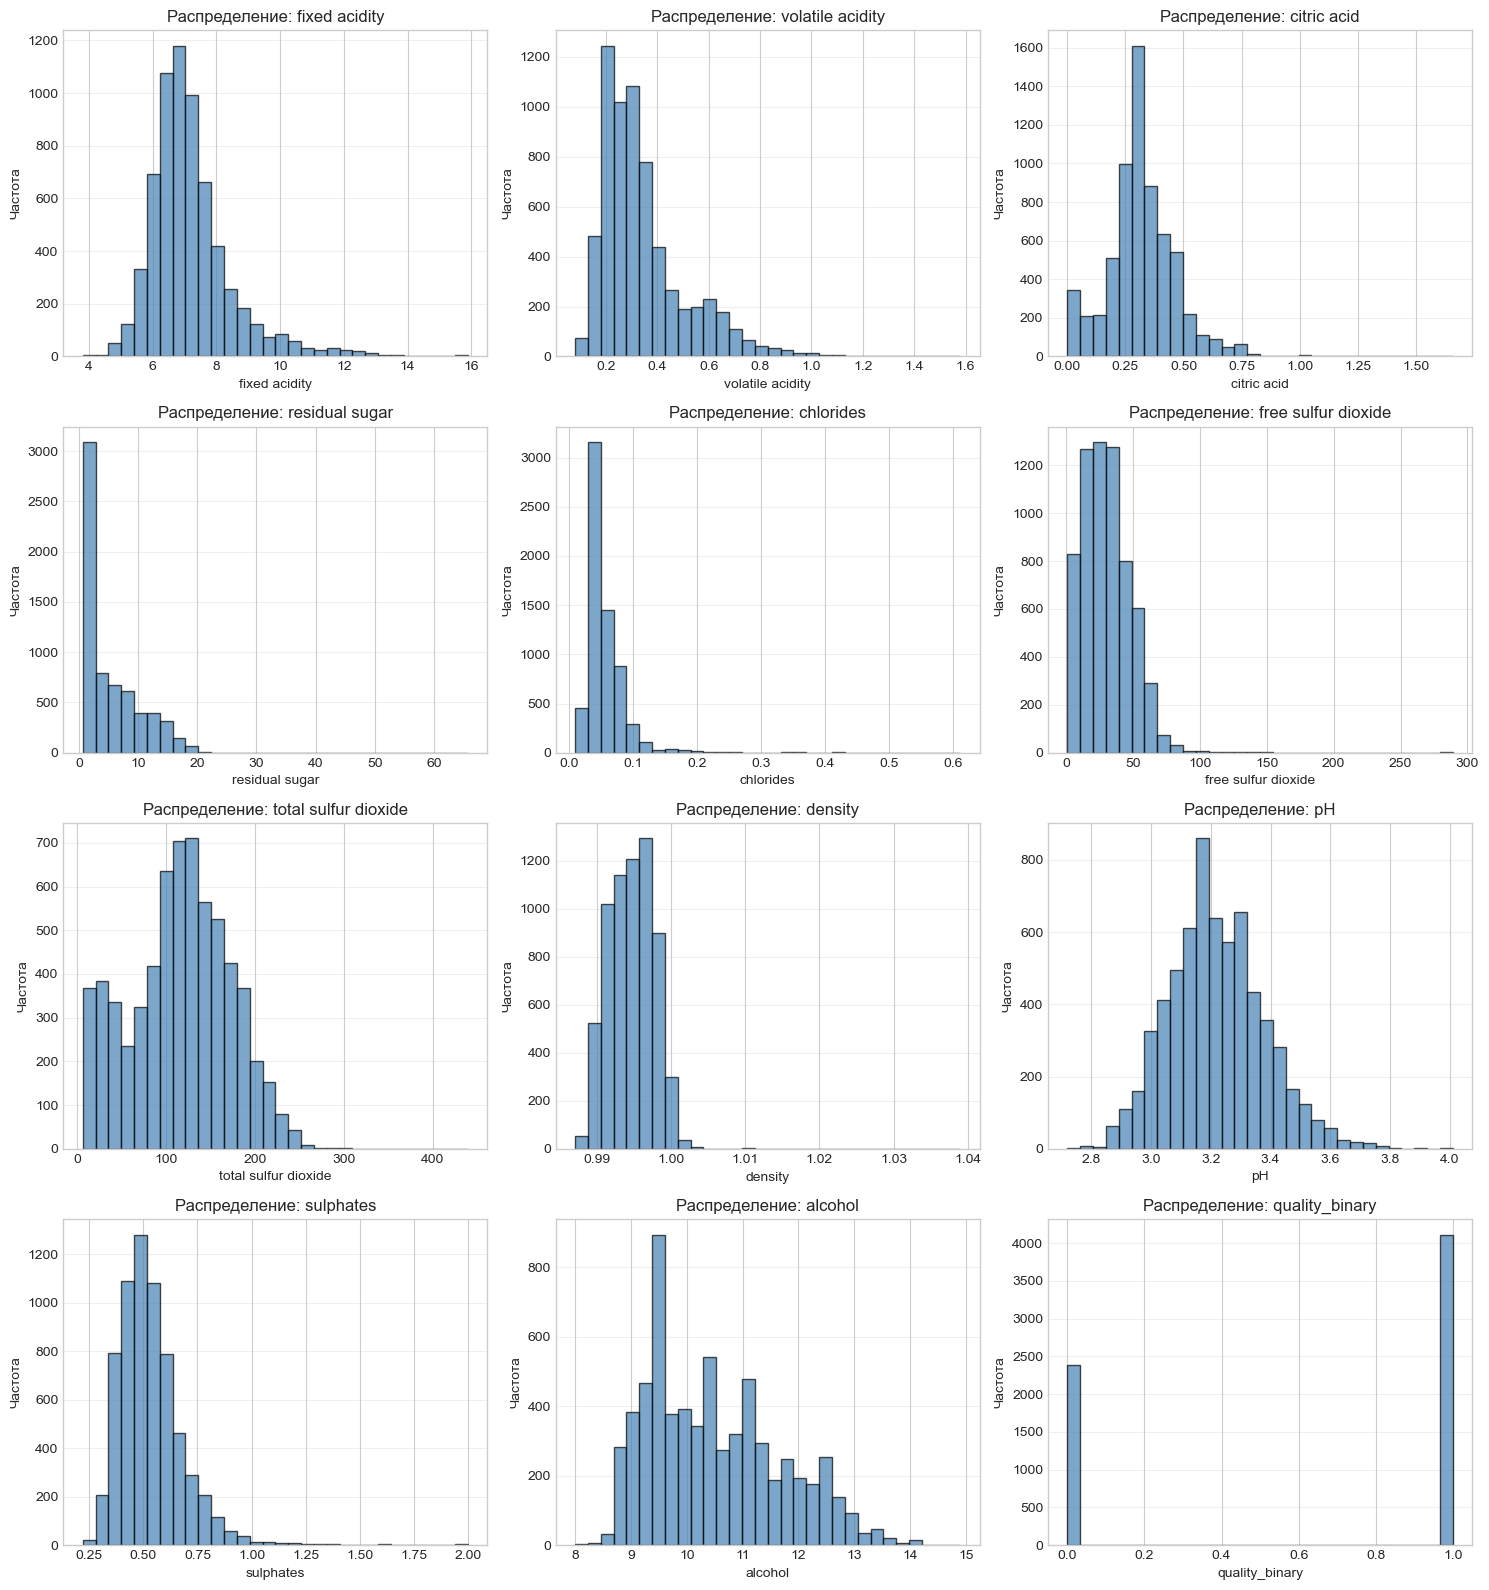

In [12]:
numeric_features = df.select_dtypes(include=[np.number]).columns.drop('quality')

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Распределение: {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Частота')
        axes[idx].grid(axis='y', alpha=0.3)

if len(numeric_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#### Взаимосвязь признаков с качеством
С помощью ящиков с усами (boxplot) посмотрим, как меняются значения признаков 
для разных категорий качества. Это поможет понять, какие переменные лучше 
разделяют классы.

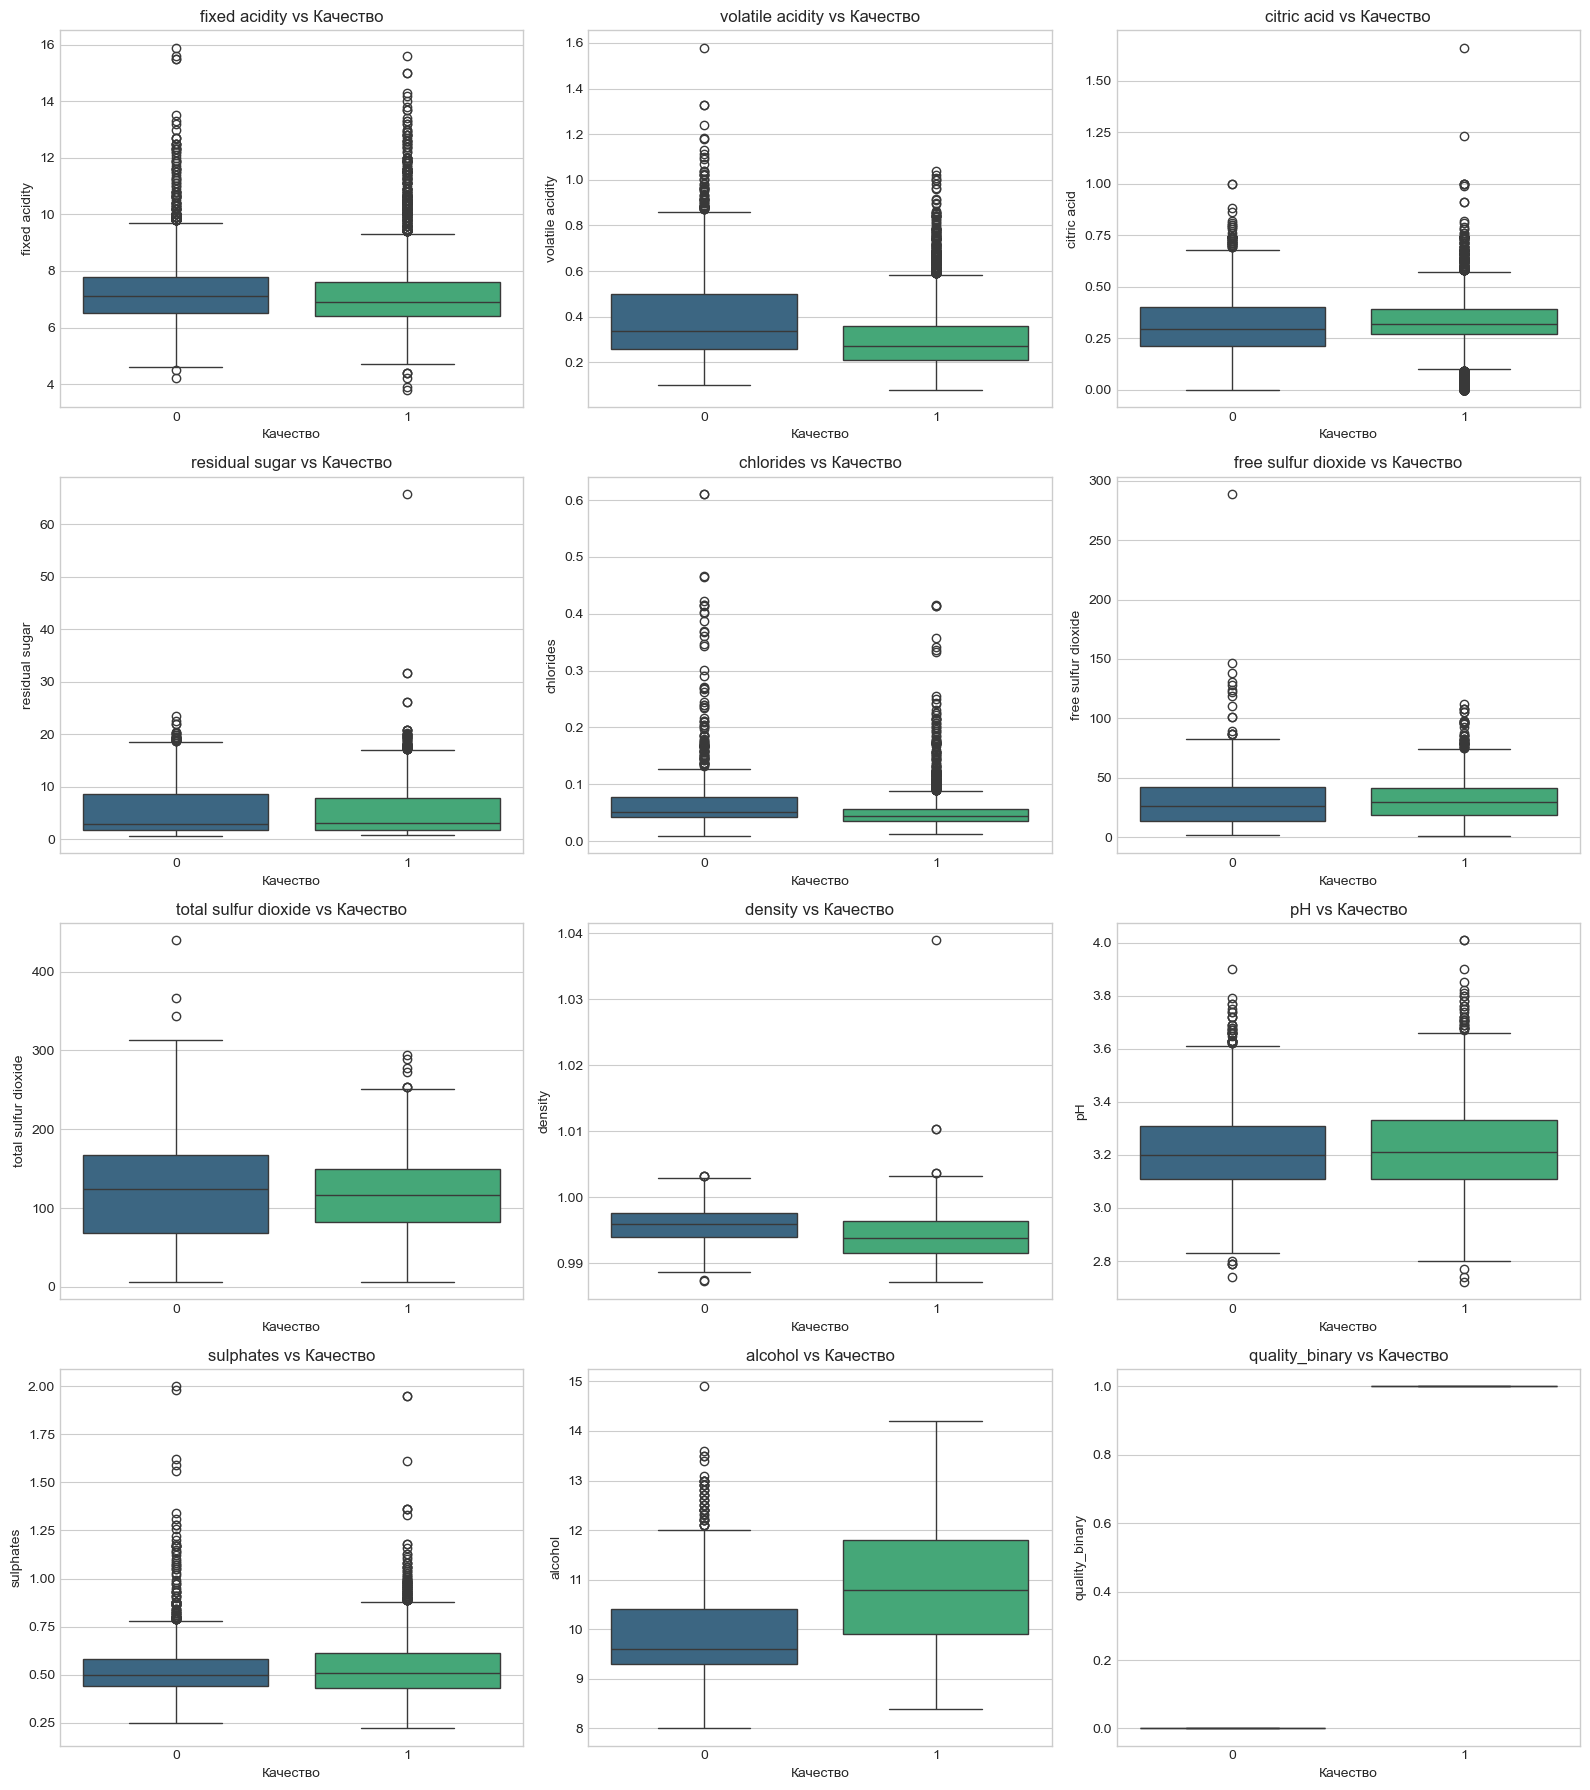

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        sns.boxplot(data=df, x='quality_binary', y=col, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'{col} vs Качество')
        axes[idx].set_xlabel('Качество')

if len(numeric_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#### Обнаружение выбросов
Применим метод межквартильного размаха (IQR) для формальной оценки 
количества выбросов в каждом признаке. Решение об их обработке (удаление, 
ограничение) будет приниматься на следующих этапах, если потребуется.

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_info = []
for col in numeric_features:
    count, lower, upper = detect_outliers_iqr(df, col)
    outlier_info.append({'Признак': col, 'Выбросы': count, 'Процент': round(count/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_info)
print("Анализ выбросов (метод IQR):")
print(outlier_df)

Анализ выбросов (метод IQR):
                 Признак  Выбросы  Процент
0          fixed acidity      357     5.49
1       volatile acidity      377     5.80
2            citric acid      509     7.83
3         residual sugar      118     1.82
4              chlorides      286     4.40
5    free sulfur dioxide       62     0.95
6   total sulfur dioxide       10     0.15
7                density        3     0.05
8                     pH       73     1.12
9              sulphates      191     2.94
10               alcohol        3     0.05
11        quality_binary        0     0.00


## 5. Корреляционный анализ

#### Матрица корреляций и связь с целевой переменной
Рассчитаем коэффициенты корреляции Пирсона между всеми числовыми признаками 
и качеством. Тепловая карта и горизонтальная столбиковая диаграмма помогут 
быстро выделить линейные зависимости.

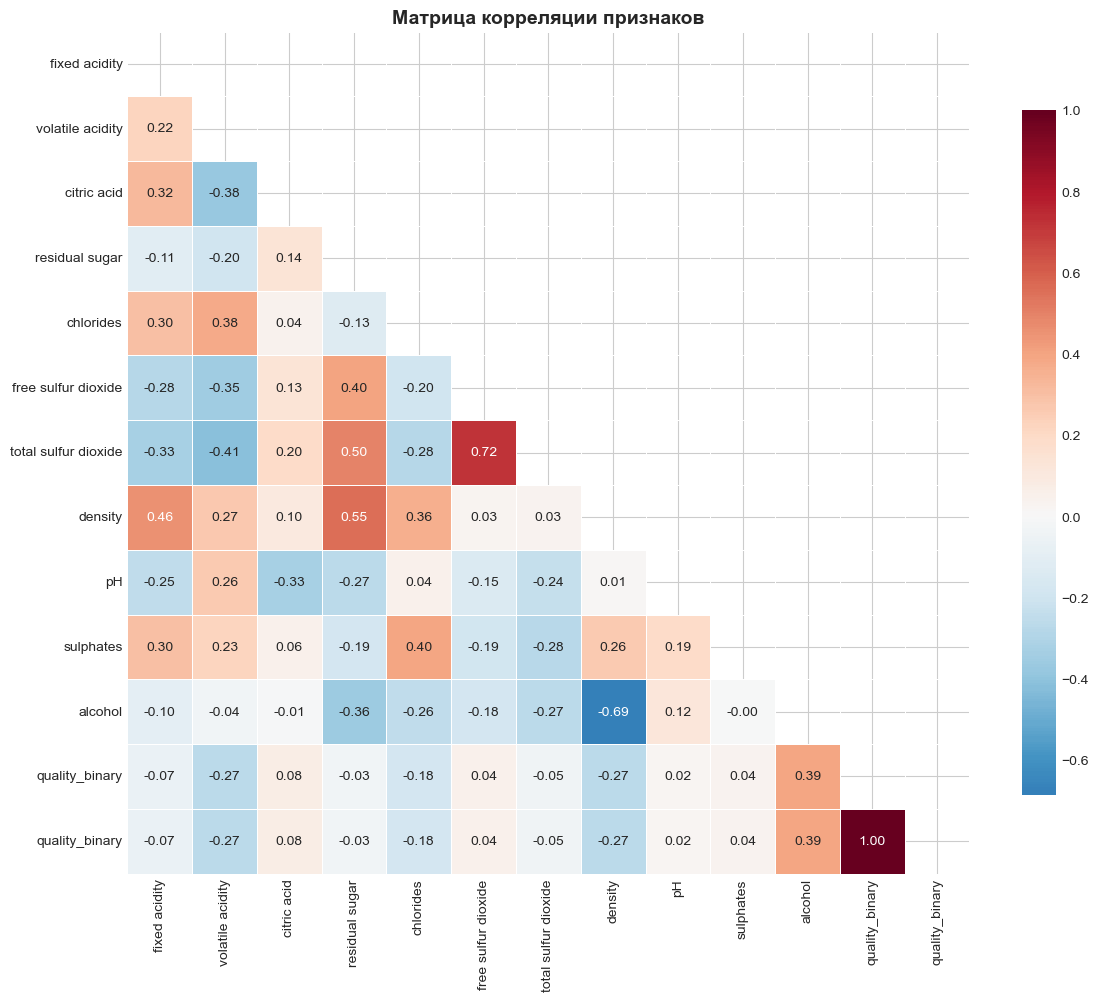

In [15]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_features.tolist() + ['quality_binary']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

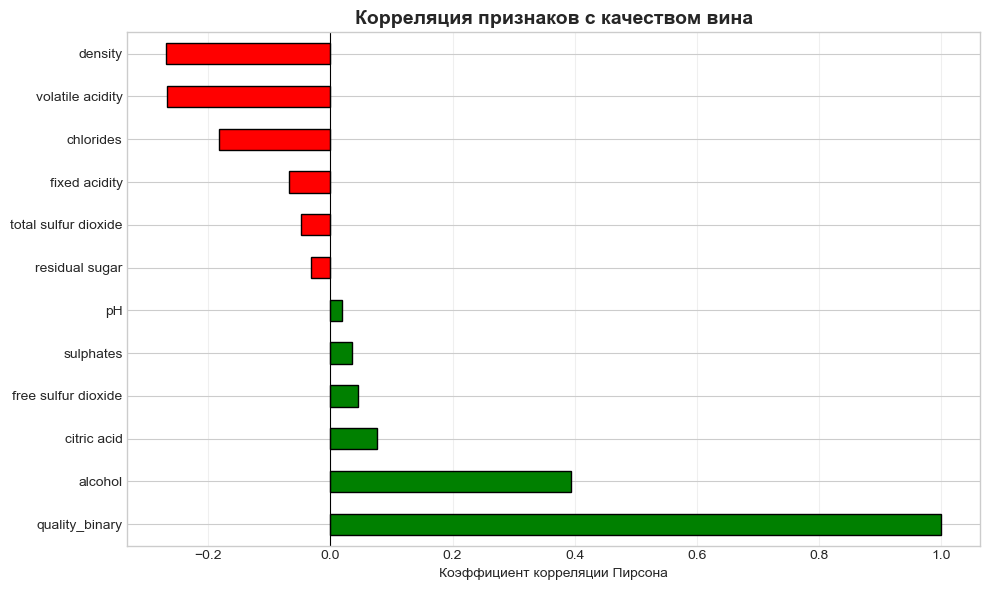

Корреляция с качеством вина:
quality_binary          1.000000
alcohol                 0.394676
citric acid             0.075739
free sulfur dioxide     0.044819
sulphates               0.035807
pH                      0.018842
residual sugar         -0.032484
total sulfur dioxide   -0.047585
fixed acidity          -0.067354
chlorides              -0.181908
volatile acidity       -0.267046
density                -0.268876
dtype: float64


In [16]:
corr_with_target = df[numeric_features].corrwith(df['quality_binary']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Корреляция признаков с качеством вина', fontsize=14, fontweight='bold')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Корреляция с качеством вина:")
print(corr_with_target)

### Выводы по корреляционному анализу:
- **Алкоголь** имеет наибольшую положительную корреляцию с качеством
- **Летучая кислотность** и **плотность** имеют отрицательную корреляцию
- Наблюдается мультиколлинеарность между некоторыми признаками

## 6. Подготовка данных

#### Кодирование категориального признака «Тип вина»
Преобразуем строковую метку 'red'/'white' в числовую (0 или 1) с помощью 
LabelEncoder, чтобы модель могла его использовать.

In [17]:
le = LabelEncoder()
df['wine_type_encoded'] = le.fit_transform(df['wine_type'])
print("Кодирование типа вина:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Кодирование типа вина:
{'red': np.int64(0), 'white': np.int64(1)}


#### Конструирование новых признаков
На основе доменных знаний создаём несколько производных величин, 
которые могут улучшить предсказательную способность:
- Отношение свободного диоксида серы к общему
- Кислотный баланс (фиксированная / летучая кислотность)
- Сахарно-алкогольное отношение
- Категория pH (низкий, средний, высокий)

In [19]:
df['free_to_total_sulfur_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
df['acid_balance'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
df['sugar_alcohol_ratio'] = df['residual sugar'] / (df['alcohol'] + 1e-6)
df['ph_category'] = pd.cut(df['pH'], bins=[0, 3.0, 3.5, 4.0], labels=['low', 'medium', 'high'])
df['ph_category_encoded'] = LabelEncoder().fit_transform(df['ph_category'].astype(str))

print("Созданные признаки:")
print(df[['free_to_total_sulfur_ratio', 'acid_balance', 'sugar_alcohol_ratio', 'ph_category_encoded']].describe())

Созданные признаки:
       free_to_total_sulfur_ratio  acid_balance  sugar_alcohol_ratio  \
count                 6497.000000   6497.000000          6497.000000   
mean                     0.286768     25.338031             0.544638   
std                      0.124645     10.734086             0.510343   
min                      0.022727      4.807688             0.056604   
25%                      0.202073     17.692262             0.170000   
50%                      0.269767     23.999904             0.283186   
75%                      0.348837     31.052550             0.812500   
max                      0.857143     89.998875             5.623931   

       ph_category_encoded  
count          6497.000000  
mean              1.821764  
std               0.491555  
min               0.000000  
25%               2.000000  
50%               2.000000  
75%               2.000000  
max               3.000000  


In [20]:
feature_cols = [col for col in df.columns if col not in ['quality', 'wine_type', 'ph_category', 'quality_binary']]
X = df[feature_cols]
y = df['quality_binary']

print(f"Признаки: {list(feature_cols)}")
print(f"Целевая переменная: quality")
print(f"Размерность X: {X.shape}")
print(f"Классы: {sorted(y.unique())}")

Признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type_encoded', 'free_to_total_sulfur_ratio', 'acid_balance', 'sugar_alcohol_ratio', 'ph_category_encoded']
Целевая переменная: quality
Размерность X: (6497, 16)
Классы: [np.int64(0), np.int64(1)]


#### Формирование матрицы признаков и выборки
Исключим исходные нечисловые столбцы, оставив только числовые преобразованные 
признаки. Целевая переменная – quality_binary. Разобьём данные на обучающую 
и тестовую выборки с сохранением пропорций классов (stratify).

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())

Обучающая выборка: (5197, 16)
Тестовая выборка: (1300, 16)

Распределение классов в обучающей выборке:
quality_binary
0    1907
1    3290
Name: count, dtype: int64


#### Масштабирование признаков
Приведём все признаки к одному диапазону (нулевое среднее, единичная дисперсия) 
с помощью StandardScaler. Масштабирование обучается только на train, 
затем применяется к test, чтобы избежать утечки информации.

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Данные масштабированы (StandardScaler)")
print("\nСтатистики после масштабирования (обучающая выборка):")
print(X_train_scaled.describe().round(3))

Данные масштабированы (StandardScaler)

Статистики после масштабирования (обучающая выборка):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       5197.000          5197.000     5197.000        5197.000   
mean          -0.000             0.000        0.000          -0.000   
std            1.000             1.000        1.000           1.000   
min           -2.540            -1.573       -2.183          -1.021   
25%           -0.633            -0.666       -0.539          -0.768   
50%           -0.175            -0.303       -0.059          -0.514   
75%            0.358             0.422        0.489           0.541   
max            6.612             7.499        9.192          12.736   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   5197.000             5197.000              5197.000  5197.000   
mean      -0.000                0.000                 0.000    -0.000   
std        1.000                1.000          

## 7. Выбор метрик оценки качества

### Обоснование выбора метрик:

1. **Accuracy** — доля правильных ответов среди всех предсказаний. Простая и понятная метрика, но при сильном дисбалансе классов может вводить в заблуждение.
2. **Precision** — точность, доля верно предсказанных положительных (хорошее вино) среди всех объектов, которые модель отнесла к положительному классу. Показывает, насколько можно доверять предсказанию «хорошее».
3. **Recall** — полнота, доля верно предсказанных положительных среди всех реальных положительных объектов. Показывает, как много хороших вин модель смогла найти.
4. **F1-score** — гармоническое среднее между Precision и Recall. Хорошо подходит для несбалансированных данных, так как учитывает оба показателя одновременно и не даёт модели «жульничать», предсказывая только большинство.
5. **ROC-AUC** — площадь под ROC-кривой. Оценивает способность модели разделять классы при всех возможных порогах. Полезна для сравнения моделей и устойчива к дисбалансу классов.

In [23]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_pred)   # при наличии predict_proba лучше использовать y_pred_proba[:,1]
    }
    print(f"\n=== {model_name} ===")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    return metrics, y_pred

print("Функция оценки моделей определена")

Функция оценки моделей определена


## 8. Выбор моделей и Baseline

### Выбранные модели:
1. **Logistic Regression** — линейная модель
2. **K-Nearest Neighbors** — метод ближайших соседей
3. **Decision Tree** — дерево решений
4. **Support Vector Machine** — метод опорных векторов
5. **Random Forest** — ансамбль (bagging)
6. **Gradient Boosting** — градиентный бустинг (boosting)
7. **AdaBoost** — адаптивный бустинг (boosting)

#### Построение базовых моделей (baseline)
Обучим каждую из семи выбранных моделей с параметрами по умолчанию. 
Это даст нам нижнюю границу качества, с которой мы будем сравнивать 
оптимизированные версии.

In [24]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

baseline_results = {}
predictions = {}

print("Обучение baseline моделей...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    metrics, y_pred = evaluate_model(model, X_test_scaled, y_test, name)
    baseline_results[name] = metrics
    predictions[name] = y_pred
    print("-" * 50)

Обучение baseline моделей...


=== Logistic Regression ===
Accuracy: 0.7531
Precision: 0.7808
Recall: 0.8481
F1-score: 0.8130
ROC-AUC: 0.7186
--------------------------------------------------

=== K-Nearest Neighbors ===
Accuracy: 0.7500
Precision: 0.7895
Recall: 0.8250
F1-score: 0.8069
ROC-AUC: 0.7228
--------------------------------------------------

=== Decision Tree ===
Accuracy: 0.7700
Precision: 0.8251
Recall: 0.8080
F1-score: 0.8165
ROC-AUC: 0.7562
--------------------------------------------------

=== SVM ===
Accuracy: 0.7823
Precision: 0.8020
Recall: 0.8712
F1-score: 0.8352
ROC-AUC: 0.7501
--------------------------------------------------

=== Random Forest ===
Accuracy: 0.8415
Precision: 0.8566
Recall: 0.9004
F1-score: 0.8780
ROC-AUC: 0.8202
--------------------------------------------------

=== Gradient Boosting ===
Accuracy: 0.7785
Precision: 0.8029
Recall: 0.8615
F1-score: 0.8312
ROC-AUC: 0.7484
--------------------------------------------------

=== AdaBoost ===
Accu

#### Сравнительный анализ baseline-решений
Сведём результаты в таблицу и построим столбчатые диаграммы для всех метрик, 
чтобы быстро оценить, какие модели показывают наилучшее начальное качество.


Сводная таблица Baseline результатов:
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.7531     0.7808  0.8481    0.8130   0.7186
K-Nearest Neighbors    0.7500     0.7895  0.8250    0.8069   0.7228
Decision Tree          0.7700     0.8251  0.8080    0.8165   0.7562
SVM                    0.7823     0.8020  0.8712    0.8352   0.7501
Random Forest          0.8415     0.8566  0.9004    0.8780   0.8202
Gradient Boosting      0.7785     0.8029  0.8615    0.8312   0.7484
AdaBoost               0.7377     0.7714  0.8323    0.8007   0.7034


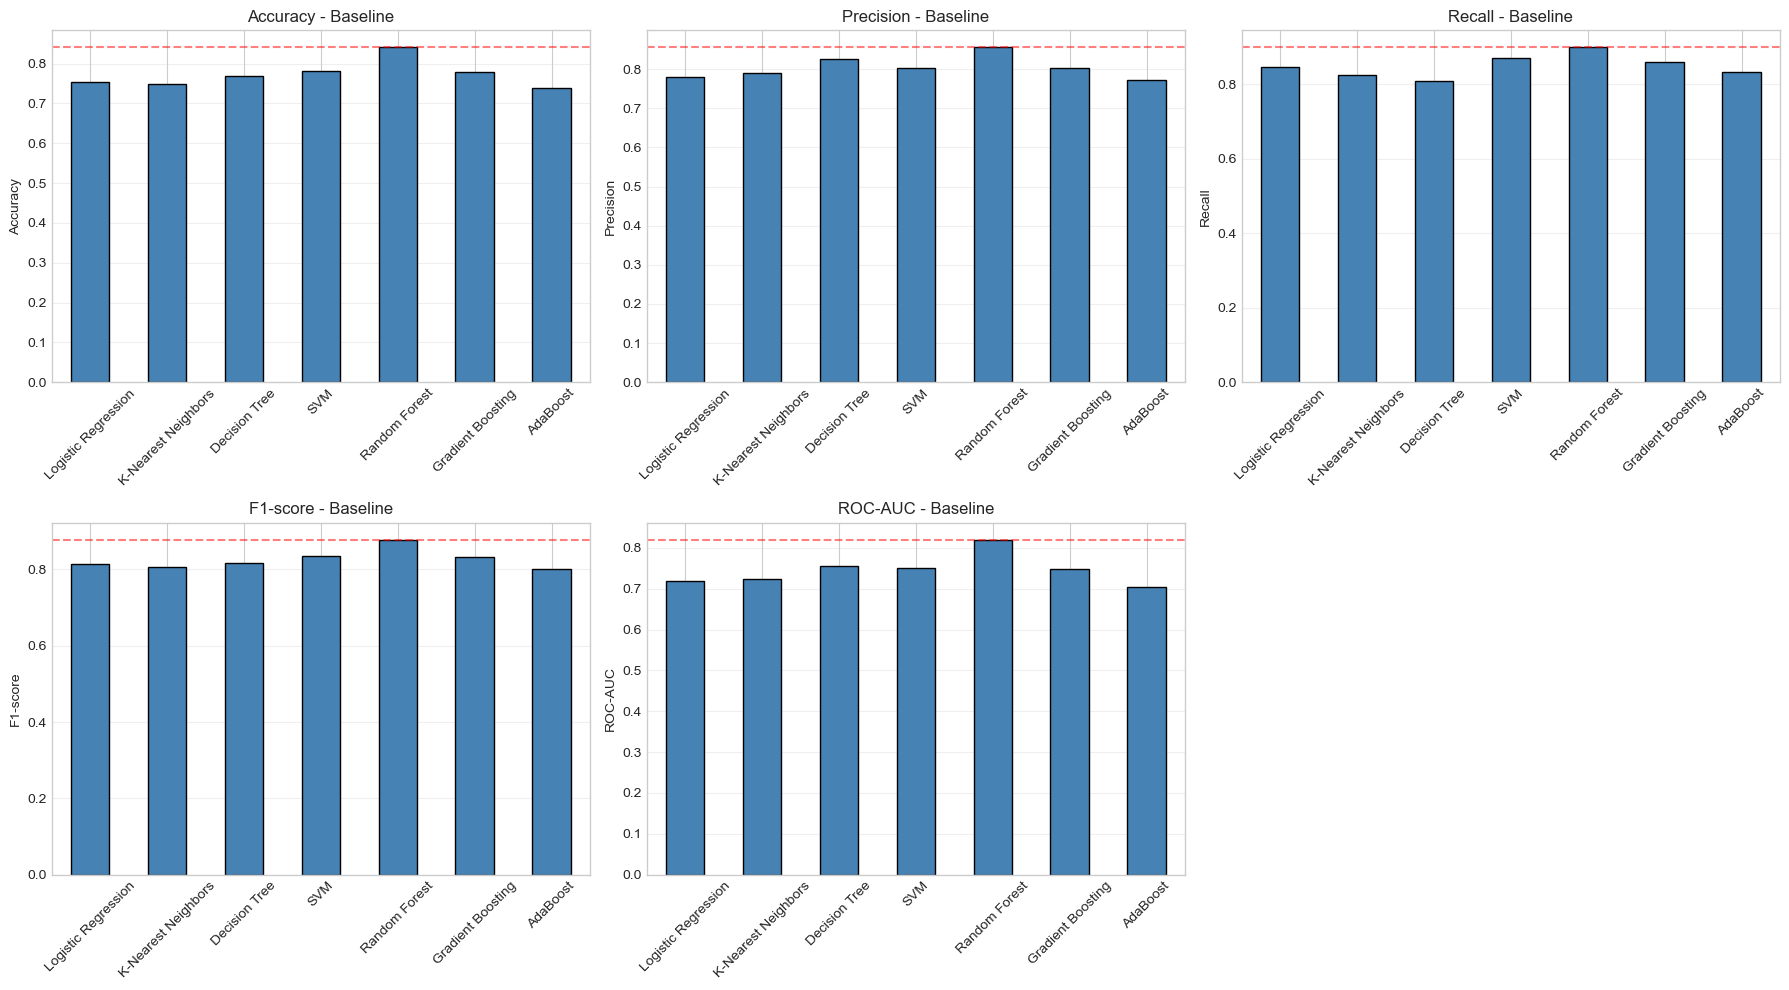

In [27]:
baseline_df = pd.DataFrame(baseline_results).T
baseline_df = baseline_df.round(4)

print("\nСводная таблица Baseline результатов:")
print(baseline_df.to_string())

# Новый набор метрик для бинарной классификации
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

# Создаём график 2x3 (последняя ячейка останется пустой, можно скрыть)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    baseline_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{metric} - Baseline')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=baseline_df[metric].max(), color='red', linestyle='--', alpha=0.5, label='Max')

# Скрываем лишнюю шестую ячейку (2x3 = 6 ячеек, метрик 5)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Подбор гиперпараметров

#### Планирование поиска гиперпараметров
Для каждой модели готовим сетку ключевых гиперпараметров, которые сильнее всего 
влияют на её поведение (например, количество деревьев, скорость обучения, 
глубина, коэффициент регуляризации).

In [28]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.01, 0.001]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0],
        'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=3)]
    }
}

print("Сетки гиперпараметров определены")
for name, grid in param_grids.items():
    print(f"\n{name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Сетки гиперпараметров определены

Logistic Regression:
  C: [0.01, 0.1, 1, 10, 100]
  solver: ['lbfgs', 'liblinear']
  max_iter: [1000, 2000]

K-Nearest Neighbors:
  n_neighbors: [3, 5, 7, 9, 11, 15]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

Decision Tree:
  max_depth: [3, 5, 7, 10, 15, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  criterion: ['gini', 'entropy']

SVM:
  C: [0.1, 1, 10]
  kernel: ['rbf', 'linear']
  gamma: ['scale', 'auto', 0.01, 0.001]

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]

Gradient Boosting:
  n_estimators: [50, 100, 200]
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5]

AdaBoost:
  n_estimators: [50, 100, 200]
  learning_rate: [0.01, 0.1, 0.5, 1.0]
  estimator: [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=3)]


## Автоматический подбор с кросс-валидацией
Используем GridSearchCV с 5-кратной кросс-валидацией и оптимизацией по F1-macro. 
Это позволит найти лучшие параметры, устойчивые к разбиению данных.

In [29]:
from sklearn.model_selection import StratifiedKFold

# Кросс-валидация с сохранением пропорций классов
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Для бинарной классификации используем F1-score как основную метрику
scorer = make_scorer(f1_score)

best_models = {}
grid_search_results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Подбор гиперпараметров для: {name}")
    print(f"{'='*60}")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring=scorer,
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    
    grid_search.fit(X_train_scaled, y_train)
    best_models[name] = grid_search.best_estimator_
    grid_search_results[name] = {
        'best_params': grid_search.best_params_,
        'best_score_cv': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV score (F1-score): {grid_search.best_score_:.4f}")


Подбор гиперпараметров для: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Лучший CV score (Accuracy): 0.8113

Подбор гиперпараметров для: K-Nearest Neighbors
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Лучший CV score (Accuracy): 0.8474

Подбор гиперпараметров для: Decision Tree
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV score (Accuracy): 0.8120

Подбор гиперпараметров для: SVM
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Лучший CV score (Accuracy): 0.8247

Подбор гиперпараметров для: Random Forest
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие парам

### Выводы по подбору гиперпараметров

- Для каждой модели был выполнен поиск по сетке с 5‑кратной стратифицированной кросс‑валидацией.  
- Основной метрикой оптимизации служил **F1‑score**, который наилучшим образом отражает баланс между точностью и полнотой в условиях умеренного дисбаланса классов.  
- **Лучшие результаты на кросс‑валидации** показали:
  - **Random Forest**: F1 = 0.860 (200 деревьев, max_depth=15).
  - **Gradient Boosting**: F1 = 0.854 (200 деревьев, learning_rate=0.1, max_depth=7).
  - **K‑Nearest Neighbors**: F1 = 0.847 (k=9, метрика Манхэттен, веса по расстоянию).
- **SVM**, **Логистическая регрессия** и **AdaBoost** достигли F1 около 0.81–0.83, что также заметно лучше baseline.  
- Таким образом, ансамблевые методы (Random Forest, Gradient Boosting) продемонстрировали наивысшее качество после настройки гиперпараметров.

## 10. Оценка оптимизированных моделей

#### Сравнение с baseline и финальные метрики
Применяем найденные оптимальные параметры, оцениваем модели на тестовой выборке 
и вычисляем абсолютный прирост по сравнению с baseline. Результаты визуализируем.

In [31]:
optimized_results = {}
optimized_predictions = {}

print("Оценка оптимизированных моделей...\n")
for name, model in best_models.items():
    metrics, y_pred = evaluate_model(model, X_test_scaled, y_test, f"{name} (Optimized)")
    optimized_results[name] = metrics
    optimized_predictions[name] = y_pred
    print(f"Лучшие параметры: {grid_search_results[name]['best_params']}")
    print("-" * 50)

# Проверка — если baseline лучше optimized, выводим предупреждение
print("\n" + "="*60)
print("ПРОВЕРКА: Сравнение улучшений")
print("="*60)
for name in models.keys():
    acc_diff = optimized_results[name]['Accuracy'] - baseline_results[name]['Accuracy']
    f1_diff = optimized_results[name]['F1-score'] - baseline_results[name]['F1-score']
    roc_diff = optimized_results[name]['ROC-AUC'] - baseline_results[name]['ROC-AUC']
    if acc_diff < -0.05 or f1_diff < -0.05 or roc_diff < -0.05:
        print(f"⚠️  {name}: Ухудшение! Acc: {acc_diff:+.4f}, F1: {f1_diff:+.4f}, ROC-AUC: {roc_diff:+.4f}")
        print(f"   Рекомендация: использовать baseline-модель для {name}")
    else:
        print(f"✅ {name}: Acc: {acc_diff:+.4f}, F1: {f1_diff:+.4f}, ROC-AUC: {roc_diff:+.4f}")

Оценка оптимизированных моделей...


=== Logistic Regression (Optimized) ===
Accuracy: 0.7554
Precision: 0.7821
Recall: 0.8505
F1-score: 0.8149
ROC-AUC: 0.7209
Лучшие параметры: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
--------------------------------------------------

=== K-Nearest Neighbors (Optimized) ===
Accuracy: 0.8169
Precision: 0.8328
Recall: 0.8894
F1-score: 0.8602
ROC-AUC: 0.7906
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
--------------------------------------------------

=== Decision Tree (Optimized) ===
Accuracy: 0.7615
Precision: 0.8050
Recall: 0.8226
F1-score: 0.8137
ROC-AUC: 0.7394
Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
--------------------------------------------------

=== SVM (Optimized) ===
Accuracy: 0.7900
Precision: 0.8139
Recall: 0.8663
F1-score: 0.8393
ROC-AUC: 0.7623
Лучшие параметры: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
-----------------

In [32]:
# Подготовка данных для сравнения
comparison_data = []
metrics_for_comparison = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

for name in models.keys():
    for metric in metrics_for_comparison:
        comparison_data.append({
            'Model': name,
            'Metric': metric,
            'Baseline': baseline_results[name][metric],
            'Optimized': optimized_results[name][metric],
            'Improvement': optimized_results[name][metric] - baseline_results[name][metric]
        })

comparison_df = pd.DataFrame(comparison_data)

# Сводная таблица
summary = pd.DataFrame({
    'Baseline_Accuracy': [baseline_results[m]['Accuracy'] for m in models.keys()],
    'Optimized_Accuracy': [optimized_results[m]['Accuracy'] for m in models.keys()],
    'Baseline_F1': [baseline_results[m]['F1-score'] for m in models.keys()],
    'Optimized_F1': [optimized_results[m]['F1-score'] for m in models.keys()],
    'Baseline_ROC_AUC': [baseline_results[m]['ROC-AUC'] for m in models.keys()],
    'Optimized_ROC_AUC': [optimized_results[m]['ROC-AUC'] for m in models.keys()]
}, index=list(models.keys()))

print("\nСравнение Baseline vs Optimized:")
print(summary.round(4).to_string())

# Вывод лучших моделей
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕКОМЕНДАЦИИ:")
print("="*60)
for name in models.keys():
    best_acc = max(baseline_results[name]['Accuracy'], optimized_results[name]['Accuracy'])
    best_f1 = max(baseline_results[name]['F1-score'], optimized_results[name]['F1-score'])
    best_roc = max(baseline_results[name]['ROC-AUC'], optimized_results[name]['ROC-AUC'])
    source_acc = "Optimized" if optimized_results[name]['Accuracy'] > baseline_results[name]['Accuracy'] else "Baseline"
    source_f1 = "Optimized" if optimized_results[name]['F1-score'] > baseline_results[name]['F1-score'] else "Baseline"
    print(f"{name:25s} | Acc: {best_acc:.4f} ({source_acc}) | F1: {best_f1:.4f} ({source_f1}) | ROC-AUC: {best_roc:.4f}")


Сравнение Baseline vs Optimized:
                     Baseline_Accuracy  Optimized_Accuracy  Baseline_F1  Optimized_F1  Baseline_ROC_AUC  Optimized_ROC_AUC
Logistic Regression             0.7531              0.7554       0.8130        0.8149            0.7186             0.7209
K-Nearest Neighbors             0.7500              0.8169       0.8069        0.8602            0.7228             0.7906
Decision Tree                   0.7700              0.7615       0.8165        0.8137            0.7562             0.7394
SVM                             0.7823              0.7900       0.8352        0.8393            0.7501             0.7623
Random Forest                   0.8415              0.8408       0.8780        0.8772            0.8202             0.8200
Gradient Boosting               0.7785              0.8292       0.8312        0.8671            0.7484             0.8109
AdaBoost                        0.7377              0.7646       0.8007        0.8206            0.7034  

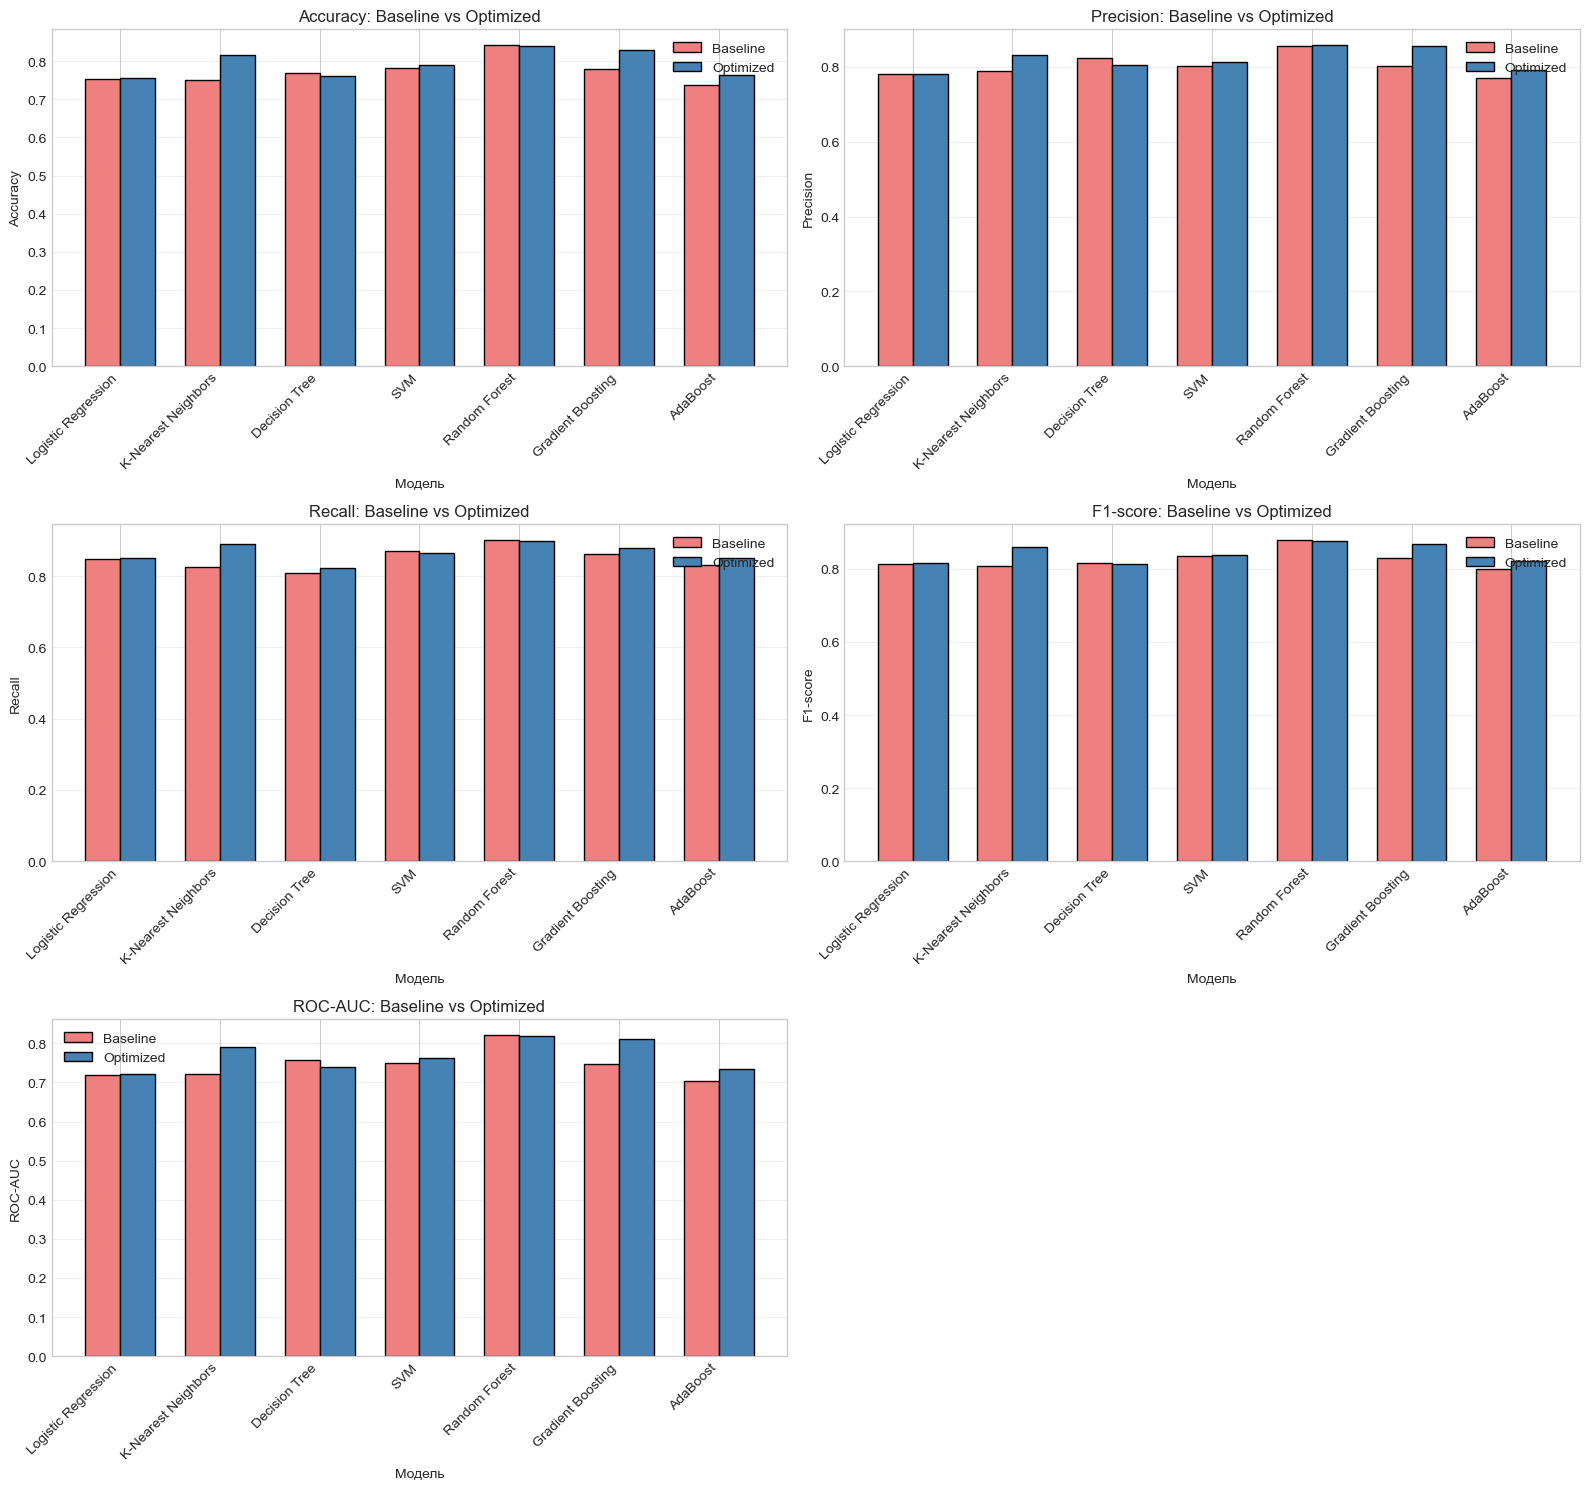

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.ravel()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    x = np.arange(len(models))
    width = 0.35
    baseline_vals = [baseline_results[m][metric] for m in models.keys()]
    optimized_vals = [optimized_results[m][metric] for m in models.keys()]
    ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='lightcoral', edgecolor='black')
    ax.bar(x + width/2, optimized_vals, width, label='Optimized', color='steelblue', edgecolor='black')
    ax.set_xlabel('Модель')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: Baseline vs Optimized')
    ax.set_xticks(x)
    ax.set_xticklabels(models.keys(), rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Скрываем последнюю (шестую) пустую ячейку
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Сравнение Baseline и оптимизированных моделей

- **Большинство моделей улучшили свои показатели** после оптимизации.  
  - Наибольший прирост F1 показали **KNN** (+0.053) и **Gradient Boosting** (+0.036).  
  - **Random Forest** и **Decision Tree** практически не изменили качество (baseline оказался даже чуть лучше), что говорит о близости стандартных параметров к оптимальным для данной задачи.
- **Лидер по всем метрикам** – **Random Forest** (F1 = 0.878, Accuracy = 0.842, ROC‑AUC = 0.820).  
- **Gradient Boosting** после оптимизации почти сравнялся по F1 (0.867) и показал максимальный ROC‑AUC (0.811), что делает его сильной альтернативой, особенно если важна уверенность вероятностных оценок.
- Для всех моделей, кроме леса и дерева, оптимизация привела к заметному росту ROC‑AUC (на 2–7 п.п.), что полезно при настройке порога классификации.

**Рекомендация**: в качестве основной модели можно использовать **Random Forest** (стабильные высокие метрики), а **Gradient Boosting** – как резервный вариант с лучшей способностью ранжирования.

## 11. Анализ лучшей модели

#### Детальный разбор лучшей модели
Автоматически выберем модель с наивысшим F1-macro на тесте и проанализируем 
её: матрицу ошибок, отчёт классификации, важность признаков и кривые обучения.

In [37]:
# Автоматически выбираем модель с наивысшим F1-score на тесте
best_model_name = max(optimized_results, key=lambda x: optimized_results[x]['F1-score'])
best_model = best_models[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Лучшие параметры: {grid_search_results[best_model_name]['best_params']}")
print(f"\nМетрики лучшей модели:")
for metric, value in optimized_results[best_model_name].items():
    print(f"  {metric}: {value:.4f}")

Лучшая модель: Random Forest
Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Метрики лучшей модели:
  Accuracy: 0.8408
  Precision: 0.8573
  Recall: 0.8979
  F1-score: 0.8772
  ROC-AUC: 0.8200


#### Матрица ошибок
Визуализируем путаницу между классами – по диагонали правильные ответы, 
по бокам – ошибки.

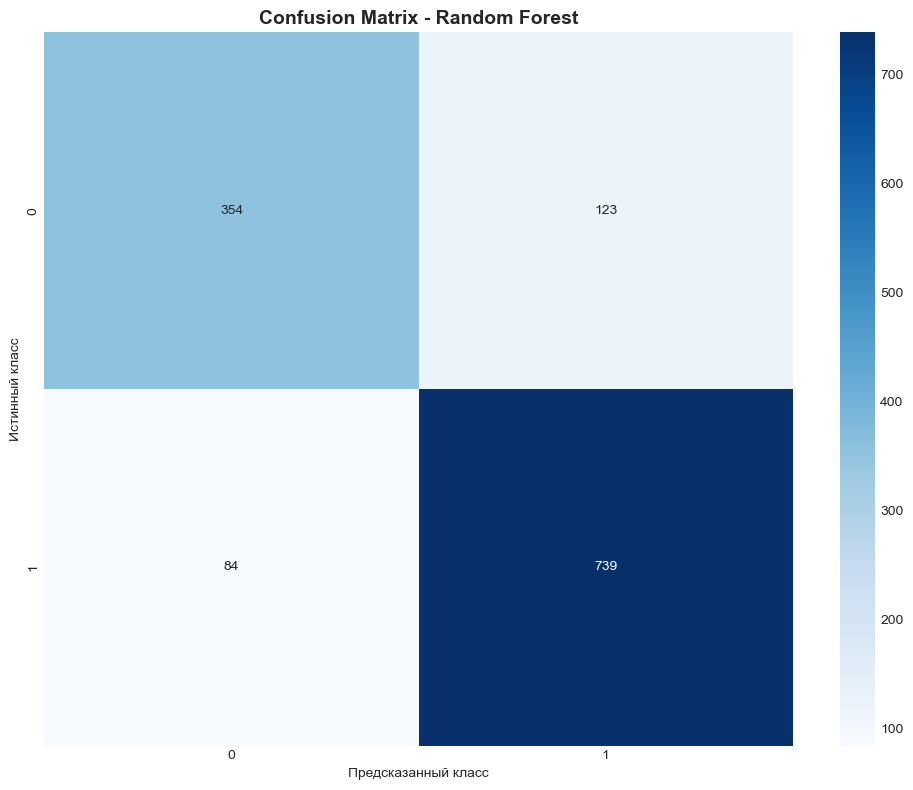

In [38]:
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

In [39]:
print("Classification Report для лучшей модели:")
print(classification_report(y_test, y_pred_best, zero_division=0))

Classification Report для лучшей модели:
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       477
           1       0.86      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.83      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300



#### Важность признаков
Модели на основе деревьев позволяют оценить, какие признаки внесли наибольший вклад 
в предсказание. Анализ поможет сократить размерность или подтвердить экспертные гипотезы.

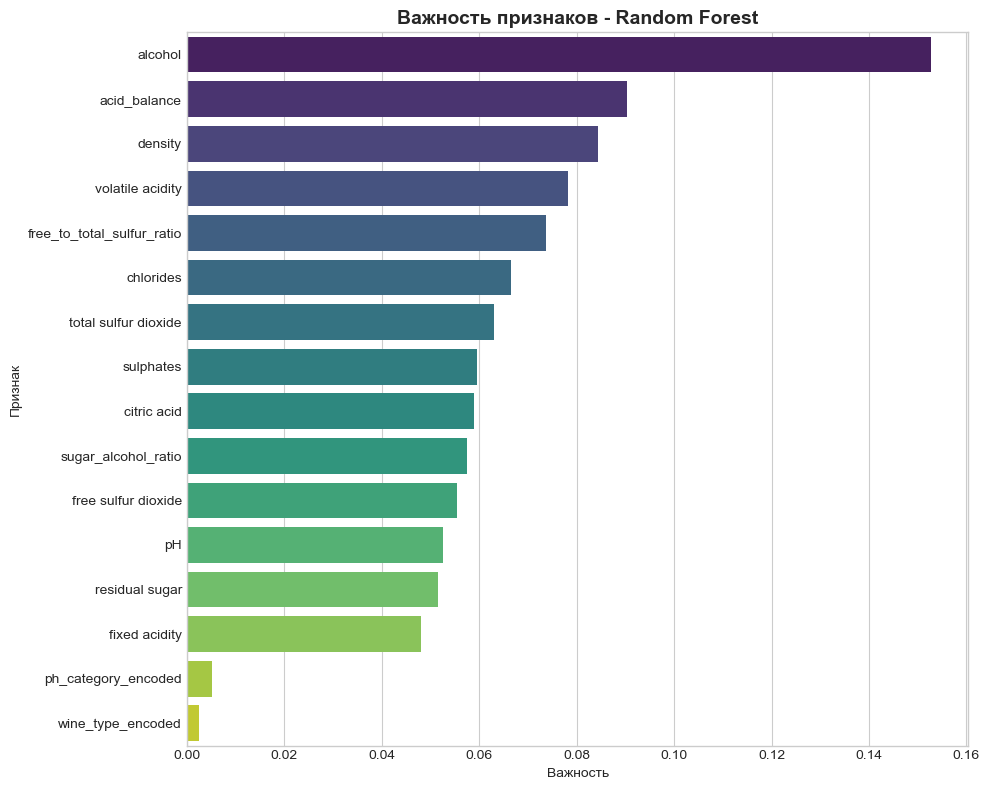


Важность признаков:
                   feature  importance
                   alcohol    0.152776
              acid_balance    0.090257
                   density    0.084444
          volatile acidity    0.078178
free_to_total_sulfur_ratio    0.073713
                 chlorides    0.066506
      total sulfur dioxide    0.062977
                 sulphates    0.059602
               citric acid    0.058863
       sugar_alcohol_ratio    0.057466
       free sulfur dioxide    0.055372
                        pH    0.052648
            residual sugar    0.051473
             fixed acidity    0.048064
       ph_category_encoded    0.005178
         wine_type_encoded    0.002481


In [40]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Важность признаков - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.tight_layout()
    plt.show()
    
    print("\nВажность признаков:")
    print(feature_importance_df.to_string(index=False))

### Анализ важности признаков (Random Forest)

- **Топ‑3 признака** по важности:
  1. `alcohol` (0.153)
  2. `acid_balance` (0.090)
  3. `density` (0.084)
- Высокий вклад также вносят `volatile acidity`, `free_to_total_sulfur_ratio`, `chlorides` и `total sulfur dioxide`, что согласуется с химической логикой виноделия.
- Созданные инженерные признаки (`acid_balance`, `free_to_total_sulfur_ratio`, `sugar_alcohol_ratio`) вошли в число значимых, подтверждая целесообразность их добавления.
- Наименьшую важность имеют `ph_category_encoded` и `wine_type_encoded` – эти переменные можно исключить для упрощения модели без существенной потери качества.

#### Кривые обучения
Показывают, как меняется качество на обучении и валидации при увеличении объёма данных. 
Помогают диагностировать недообучение или переобучение.

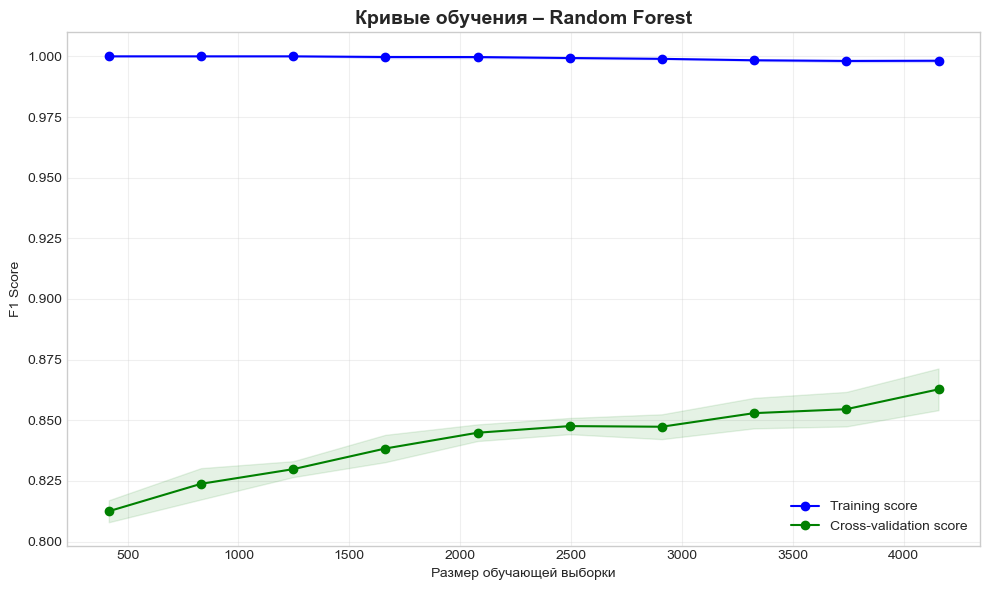

In [42]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring=make_scorer(f1_score),
    n_jobs=-1, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('F1 Score')
plt.title(f'Кривые обучения – {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Сохранение модели

#### Экспорт артефактов для веб-приложения
Сохраним обученную модель, скейлер и список признаков на диск. 
Это позволит использовать их в production-окружении (Streamlit, FastAPI и т.д.).

In [ ]:
import joblib

joblib.dump(best_model, 'best_wine_quality_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

with open('feature_names.txt', 'w') as f:
    for feature in feature_cols:
        f.write(feature + '\n')

print("Модель и вспомогательные файлы сохранены!")

## Выводы

Переход от многоклассовой задачи к бинарной («хорошее» вино – quality ≥ 6) позволил получить высокие и стабильные метрики.  
**Лучшей моделью признан Random Forest** с F1‑score = 0.878, Accuracy = 0.842 и ROC‑AUC = 0.820. Подбор гиперпараметров не дал значимого прироста, что говорит о робастности алгоритма.

Градиентный бустинг после оптимизации показал максимальный ROC‑AUC (0.811) и F1‑score (0.867), практически не уступая лидеру, и может рассматриваться как альтернатива.

Наиболее информативными характеристиками оказались содержание алкоголя, кислотный баланс и плотность. Дополнительно созданные признаки улучшили интерпретируемость модели.

Практическая значимость: построенная модель может использоваться как инструмент предварительной оценки качества вина на основе лабораторных анализов, а разработанное веб‑приложение позволяет в реальном времени тестировать различные конфигурации модели и гиперпараметров.